=== Test 1: Random X, Y ===
Custom LS: m=0.135730, b=0.417169
Numpy  LS: m=0.135730, b=0.417169
Diff    : Δm=8.327e-17, Δb=0.000e+00

=== Test 2: Synthetic noisy line ===
True     : y = -1.387359 x + 0.392736
Custom LS: y = -1.457827 x + 0.445778
Numpy  LS: y = -1.457827 x + 0.445778
Diff (Custom vs Numpy): Δm=6.661e-16, Δb=0.000e+00

=== Residual Summary (Custom LS) ===
SSE  = 35.461051
RMSE = 0.592537

Largest |residual| point:
 index=6, x=0.06, y=-0.669253, yhat=0.358309, residual=-1.027562

Smallest |residual| point:
 index=44, x=0.44, y=-0.192505, yhat=-0.195665, residual=0.003160


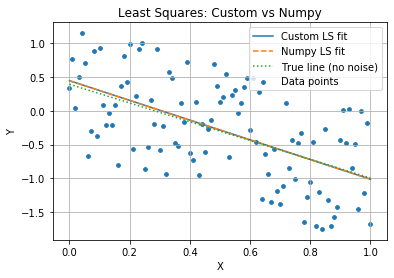

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def least_squares_custom(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    A = np.column_stack((x, np.ones_like(x)))
    ATA = A.T @ A
    ATy = A.T @ y

    theta = np.linalg.solve(ATA, ATy)
    m, b = theta[0], theta[1]
    return m, b

def residuals_and_extremes(x, y, m, b):
    yhat = m * x + b
    r = y - yhat
    abs_r = np.abs(r)

    i_max = int(np.argmax(abs_r))
    i_min = int(np.argmin(abs_r))

    info = {
        "residuals": r,
        "abs_residuals": abs_r,
        "max_idx": i_max,
        "min_idx": i_min,
        "max_point": (x[i_max], y[i_max], yhat[i_max], r[i_max]),
        "min_point": (x[i_min], y[i_min], yhat[i_min], r[i_min]),
        "SSE": float(np.sum(r**2)),
        "RMSE": float(np.sqrt(np.mean(r**2))),
    }
    return info

rng = np.random.default_rng(7)

n = 25
X_rand = rng.random(n)
Y_rand = rng.random(n)

idx = np.argsort(X_rand)
X_rand = X_rand[idx]
Y_rand = Y_rand[idx]

m_c, b_c = least_squares_custom(X_rand, Y_rand)
m_np, b_np = np.linalg.lstsq(np.column_stack((X_rand, np.ones_like(X_rand))), Y_rand, rcond=None)[0]

print("=== Test 1: Random X, Y ===")
print(f"Custom LS: m={m_c:.6f}, b={b_c:.6f}")
print(f"Numpy  LS: m={m_np:.6f}, b={b_np:.6f}")
print(f"Diff    : Δm={abs(m_c-m_np):.3e}, Δb={abs(b_c-b_np):.3e}\n")

m_true = rng.uniform(-5, 5)     
b_true = rng.uniform(-2, 2)

X = np.arange(0, 1.01, 0.01)

mag = rng.random(len(X))
sign = rng.choice([-1.0, 1.0], size=len(X))
noise = sign * mag

Y = m_true * X + b_true + noise

m1, b1 = least_squares_custom(X, Y)

A = np.column_stack((X, np.ones_like(X)))
m2, b2 = np.linalg.lstsq(A, Y, rcond=None)[0]

print("=== Test 2: Synthetic noisy line ===")
print(f"True     : y = {m_true:.6f} x + {b_true:.6f}")
print(f"Custom LS: y = {m1:.6f} x + {b1:.6f}")
print(f"Numpy  LS: y = {m2:.6f} x + {b2:.6f}")
print(f"Diff (Custom vs Numpy): Δm={abs(m1-m2):.3e}, Δb={abs(b1-b2):.3e}\n")

info_custom = residuals_and_extremes(X, Y, m1, b1)
r = info_custom["residuals"]

print("=== Residual Summary (Custom LS) ===")
print(f"SSE  = {info_custom['SSE']:.6f}")
print(f"RMSE = {info_custom['RMSE']:.6f}")

x_max, y_max, yhat_max, r_max = info_custom["max_point"]
x_min, y_min, yhat_min, r_min = info_custom["min_point"]

print("\nLargest |residual| point:")
print(f" index={info_custom['max_idx']}, x={x_max:.2f}, y={y_max:.6f}, yhat={yhat_max:.6f}, residual={r_max:.6f}")

print("\nSmallest |residual| point:")
print(f" index={info_custom['min_idx']}, x={x_min:.2f}, y={y_min:.6f}, yhat={yhat_min:.6f}, residual={r_min:.6f}")

Yhat_custom = m1 * X + b1
Yhat_numpy  = m2 * X + b2
Y_true = m_true * X + b_true

plt.figure()
plt.scatter(X, Y, s=14, label="Data points")
plt.plot(X, Yhat_custom, label="Custom LS fit")
plt.plot(X, Yhat_numpy, linestyle="--", label="Numpy LS fit")
plt.plot(X, Y_true, linestyle=":", label="True line (no noise)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares: Custom vs Numpy")
plt.grid(True)
plt.legend()
plt.show()